<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
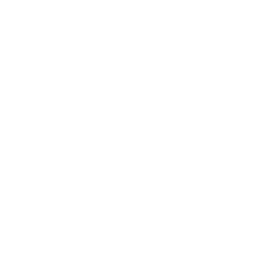
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">Perfilado de Montos de Transacciones Bancarias</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; Banca Minorista / Analítica de Clientes &nbsp;|&nbsp; Marzo de 2026</p>
</div>
</div>
</div>

## Resumen Ejecutivo

Este ejemplo perfila los montos de transacciones de banca minorista con PROC MEANS. Utiliza procesamiento de clases multi-vía (`WAYS 1 2`) para producir resúmenes de una vía y de dos vías de `TXN_AMOUNT` por canal y segmento de cliente en un solo paso, con procesamiento BY-group dividiendo cada perfil por región. Un segundo paso de PROC MEANS deriva percentiles de cola superior (P95, P99) por región y canal como umbrales candidatos para alertas de prevención de lavado de dinero. La narrativa a continuación se basa completamente en los valores que el procedimiento realmente produjo en este libro mayor de 100 transacciones.


## Fuentes de Datos

| Fuente | Descripción | Registros |
|--------|-------------|--------|
| WORK.BANK_TRANSACTIONS | Libro mayor sintético de transacciones de banca minorista con región, canal y segmento de cliente | 100 |


---

In [1]:
/* --------------------------------------------------------
   Generar un libro mayor sintético de transacciones de banca
   minorista. Este ejemplo se ejecuta en modo sin licencia, que
   limita la salida a 100 observaciones, por lo que dimensionamos
   el libro mayor a exactamente 100 transacciones y mantenemos la
   grilla de clasificación compacta (2 regiones x 3 canales x 3
   segmentos). Eso mantiene cada celda multi-vía suficientemente
   poblada para que las medias, desviaciones estándar y percentiles
   sean informativos.
   -------------------------------------------------------- */
DATOS work.bank_transactions;
    LLAMAR streaminit(42);
    LONGITUD region $12 channel $13 segment $12;
    ETIQUETA region     = "Región"
          channel    = "Canal"
          segment    = "Segmento de Cliente"
          txn_amount = "Monto de Transacción"
          txn_date   = "Fecha de Transacción"
          account_id = "ID de Cuenta";
    HACER txn_id = 1 HASTA 100;
        region_idx = int(rand('uniform') * 2) + 1;
        SI region_idx = 1 ENTONCES region = "NORESTE";
        SINO region = "OESTE";

        channel_idx = int(rand('uniform') * 3) + 1;
        SI channel_idx = 1 ENTONCES channel = "SUCURSAL";
        SINO SI channel_idx = 2 ENTONCES channel = "EN LÍNEA";
        SINO channel = "TRANSFERENCIA";

        segment_idx = int(rand('uniform') * 3) + 1;
        SI segment_idx = 1 ENTONCES segment = "MASIVO";
        SINO SI segment_idx = 2 ENTONCES segment = "ACAUDALADO";
        SINO segment = "PREFERENTE";

        /* El monto escala con el nivel de valor del segmento de cliente */
        SI segment = "PREFERENTE" ENTONCES
            txn_amount = round(rand('exponential') * 4000 + 100, 0.01);
        SINO SI segment = "ACAUDALADO" ENTONCES
            txn_amount = round(rand('exponential') * 1500 + 50, 0.01);
        SINO
            txn_amount = round(rand('exponential') * 500 + 10, 0.01);
        /* Las transferencias registran montos considerablemente mayores */
        SI channel = "TRANSFERENCIA" ENTONCES
            txn_amount = txn_amount * 3;
        txn_date = '01JAN2026'd + int(rand('uniform') * 90);
        account_id = cat('ACCT-', PUT(int(rand('uniform') * 5000) + 1, z6.));
        SALIDA;
    END;
    ELIMINAR region_idx channel_idx segment_idx;
    FORMATO txn_date date9. txn_amount dollar12.2;
EJECUTAR;



NOTE: DATA work.bank_transactions


NOTE: Wrote work.bank_transactions (100 rows, 7 columns).
NOTE: DATA elapsed:
  wall  0.03 seconds
  cpu   0.03 seconds


---

In [2]:
/* --------------------------------------------------------
   Volumen base de transacciones por region y canal
   -------------------------------------------------------- */
PROC SQL;
    SELECCIONAR region ETIQUETA="Región", channel ETIQUETA="Canal",
           count(*) AS n_txns ETIQUETA="Núm. de Transacciones",
           sum(txn_amount) AS total_amount FORMATO=dollar14.2 ETIQUETA="Monto Total"
    DESDE work.bank_transactions
    GROUP POR region, channel
    ORDER POR region, channel;
QUIT;


 Región          Canal   Núm. de Transacciones  Monto Total
-------  -------------  ----------------------  -----------
NORESTE       EN LÍNEA                      19   $60,649.49
NORESTE       SUCURSAL                      20   $44,287.32
NORESTE  TRANSFERENCIA                      14   $65,506.08
  OESTE       EN LÍNEA                      24   $43,677.03
  OESTE       SUCURSAL                       9   $23,436.62
  OESTE  TRANSFERENCIA                      14   $75,894.42



NOTE: PROC SQL 

NOTE: PROC SQL statement used.


---


NOTE: PROC SGPLOT data=work.bank_transactions

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


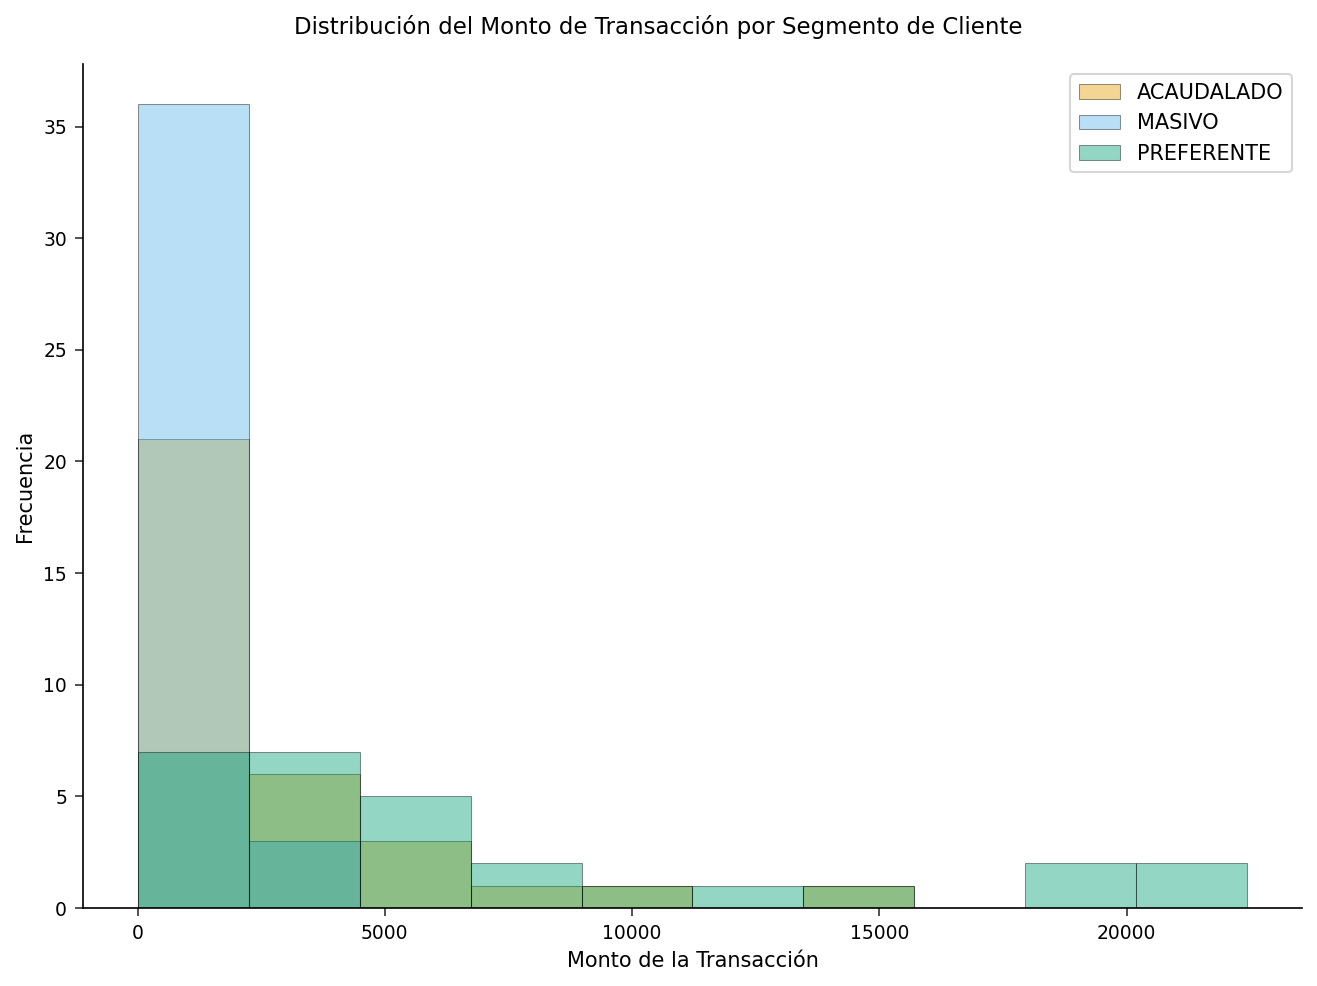

In [3]:
/* --------------------------------------------------------
   Distribucion de los montos de transaccion por segmento de cliente
   -------------------------------------------------------- */
PROC SGPLOT DATOS=work.bank_transactions;
    HISTOGRAM txn_amount / GROUP=segment TRANSPARENCY=0.4;
    XAXIS label="Monto de la Transacción";
    YAXIS label="Frecuencia";
    TÍTULO "Distribución del Monto de Transacción por Segmento de Cliente";
EJECUTAR;


---

In [4]:
/* --------------------------------------------------------
   Ordenar por region para procesamiento BY-group
   -------------------------------------------------------- */
PROC SORT DATOS=work.bank_transactions;
    POR region;
EJECUTAR;



NOTE: PROC SORT data=work.bank_transactions

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 100 rows from work.bank_transactions.
NOTE: Wrote work.bank_transactions (100 rows, 7 columns).
NOTE: PROC SORT statement used.


In [5]:
/* --------------------------------------------------------
   Perfilado multi-via. WAYS 1 2 genera cada combinacion de una
   via y de dos vias de las variables de clase en un solo paso;
   BY region produce un perfil separado por region. AUTONAME
   agrega el sufijo de cada estadistica al nombre de la variable
   de analisis en el conjunto de datos de salida.
   -------------------------------------------------------- */
PROC MEANS DATOS=work.bank_transactions n mean std MIN MAX q1 q3 MEDIAN;
    POR region;
    CLASE channel segment;
    ETIQUETA region = "Región" channel = "Canal" segment = "Segmento de Cliente"
          txn_amount = "Monto de Transacción";
    WAYS 1 2;
    VAR txn_amount;
    SALIDA out=work.txn_profile
        n= mean= std= MIN= MAX= MEDIAN= q1= q3= / autoname;
EJECUTAR;


--------------------------------------------------- Región=NORESTE ----------------------------------------------------

                                                  The MEANS Procedure

                                  Analysis Variable : txn_amount Monto de Transacción

        Canal          Segmento de Cliente          N Obs           Mean        Std Dev        Minimum        Maximum  Lower Quartile  Upper Quartile         Median
        ------------------------------------------------------------------------------------------------------------------------------------------------------------
        EN LÍNEA       ACAUDALADO                       3        $439.32        $401.53        $100.38        $882.77         $100.38         $882.77        $334.80
        EN LÍNEA       MASIVO                           6        $427.08        $515.23         $91.12      $1,451.42         $153.98         $416.41        $224.79
        EN LÍNEA       PREFERENTE                      10    


NOTE: PROC MEANS
NOTE: Output dataset work.txn_profile has 30 observations and 13 variables.
NOTE: PROC MEANS statement used.


In [6]:
/* --------------------------------------------------------
   Extraer el resumen de una via por canal (_TYPE_ = 2, donde solo
   CHANNEL esta activo) para una vista de panel a nivel de canal.
   -------------------------------------------------------- */
PROC SQL;
    SELECCIONAR region ETIQUETA="Región", channel ETIQUETA="Canal",
           txn_amount_n AS n_transactions ETIQUETA="Núm. de Transacciones",
           txn_amount_mean AS avg_amount FORMATO=dollar12.2 ETIQUETA="Monto Promedio",
           txn_amount_median AS median_amount FORMATO=dollar12.2 ETIQUETA="Monto Mediano",
           txn_amount_stddev AS std_amount FORMATO=dollar12.2 ETIQUETA="Desv. Estándar"
    DESDE work.txn_profile
    DONDE _type_ = 2
    ORDER POR region, channel;
QUIT;


 Región          Canal   Núm. de Transacciones  Monto Promedio  Monto Mediano   Desv. Estándar
-------  -------------  ----------------------  --------------  -------------  ---------------
NORESTE       EN LÍNEA                    19.0       $3,192.08      $1,451.42        $4,749.86
NORESTE       SUCURSAL                    20.0       $2,214.37      $1,065.89        $3,254.59
NORESTE  TRANSFERENCIA                    14.0       $4,679.01      $2,415.73        $5,593.67
  OESTE       EN LÍNEA                    24.0       $1,819.88        $363.46        $4,602.84
  OESTE       SUCURSAL                     9.0       $2,604.07      $3,019.18        $2,308.55
  OESTE  TRANSFERENCIA                    14.0       $5,421.03      $2,985.11        $6,046.75



NOTE: PROC SQL 

NOTE: PROC SQL statement used.


In [7]:
/* --------------------------------------------------------
   Umbrales de cola superior: P95, P99 y el maximo por region y
   canal. En produccion estas estimaciones de cola alimentan la
   calibracion de alertas de prevencion de lavado de dinero. En un
   libro mayor de 100 filas los conteos por celda son pequenos, por
   lo que los percentiles son ilustrativos y no estan calibrados.
   -------------------------------------------------------- */
PROC MEANS DATOS=work.bank_transactions p95 p99 MAX;
    POR region;
    CLASE channel;
    ETIQUETA region = "Región" channel = "Canal" txn_amount = "Monto de Transacción";
    VAR txn_amount;
    SALIDA out=work.aml_thresholds
        p95= p99= MAX= / autoname;
EJECUTAR;


--------------------------------------------------- Región=NORESTE ----------------------------------------------------

                                                  The MEANS Procedure

                                 Analysis Variable : txn_amount Monto de Transacción

                                             N
                          Canal            Obs       95th Pctl       99th Pctl         Maximum
                          --------------------------------------------------------------------
                          EN LÍNEA          19      $18,941.55      $18,941.55      $18,941.55
                          SUCURSAL          20      $10,676.57      $13,443.41      $13,443.41
                          TRANSFERENCIA     14      $18,534.36      $18,534.36      $18,534.36
                          --------------------------------------------------------------------


---------------------------------------------------- Región=OESTE -------------------------------------


NOTE: PROC MEANS
NOTE: Output dataset work.aml_thresholds has 8 observations and 7 variables.
NOTE: PROC MEANS statement used.


---

### Interpretación

El perfil multi-vía confirma que el segmento de cliente y el canal impulsan conjuntamente el tamaño de la transacción. Dentro de las celdas de dos vías (canal x segmento), los clientes PREFERENTE registran los montos promedio más altos en cada canal donde aparecen: en Oeste, las transacciones PREFERENTE en línea promedian \$8,879.75 (n=4, máx \$22,431.64) y las transacciones PREFERENTE por transferencia promedian \$11,119.84 (n=4, máx \$21,880.47), frente a Oeste en línea MASIVO en \$289.91 y Oeste sucursal MASIVO en \$443.53. En Noreste, PREFERENTE en línea promedia \$5,676.90 en 10 transacciones mientras que MASIVO en línea promedia \$427.08 — una brecha de un orden de magnitud que convierte al segmento PREFERENTE en el predictor dominante del valor de la transacción.

El paso de percentiles ilustra cómo PROC MEANS alimenta la calibración de umbrales. En este libro mayor de 100 filas los conteos por celda son pequeños, por lo que las estimaciones P95/P99 se ubican cerca del máximo de cada celda: Oeste en línea alcanza un P99 de \$22,431.64 y Oeste transferencia de \$21,880.47, mientras que Noreste en línea llega a \$18,941.55. La celda de una sola observación de Noreste PREFERENTE transferencia (\$18,534.36, desviación estándar faltante) es un recordatorio de que las celdas delgadas producen estimaciones de cola inestables — en producción estos umbrales se recalcularían sobre el libro mayor completo, pero la mecánica del procedimiento mostrada aquí es exactamente lo que un analista ejecutaría. El histograma anterior muestra la distribución de montos sesgada a la derecha esperada, con el segmento PREFERENTE extendiéndose más lejos hacia la cola superior.


---

In [8]:
/* --------------------------------------------------------
   Exportar las tablas de perfilado y de umbrales AML
   -------------------------------------------------------- */
PROC EXPORT DATOS=work.txn_profile
    OUTFILE='perfiles_transacciones.csv'
    DBMS=csv REPLACE;
EJECUTAR;

PROC EXPORT DATOS=work.aml_thresholds
    OUTFILE='umbrales_aml_por_region.csv'
    DBMS=csv REPLACE;
EJECUTAR;



NOTE: PROC EXPORT data=work.txn_profile outfile=perfiles_transacciones.csv

NOTE: Exported 30 rows to perfiles_transacciones.csv.
NOTE: PROC EXPORT data=work.aml_thresholds outfile=umbrales_aml_por_region.csv

NOTE: Exported 8 rows to umbrales_aml_por_region.csv.


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; Confidencial
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Con tecnología de <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>